# Mask detection - step 1: edges

First block of the automatic mask-detection pipeline. We compute edges
(Canny, Sobel) and see how the patch region stands out. No mask
extraction yet — just looking and tuning thresholds.

In [6]:
import sys
sys.path.insert(0, "..")

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt

from src.data.loading import load_image
from src.data.inventory import find_images
from src.detection.edges import to_gray, canny_edges, sobel_edges

In [8]:
DATA_DIR = Path("../data")
samples = find_images(DATA_DIR)
img = load_image(samples[0])
gray = to_gray(img)

## Grayscale, Canny, Sobel

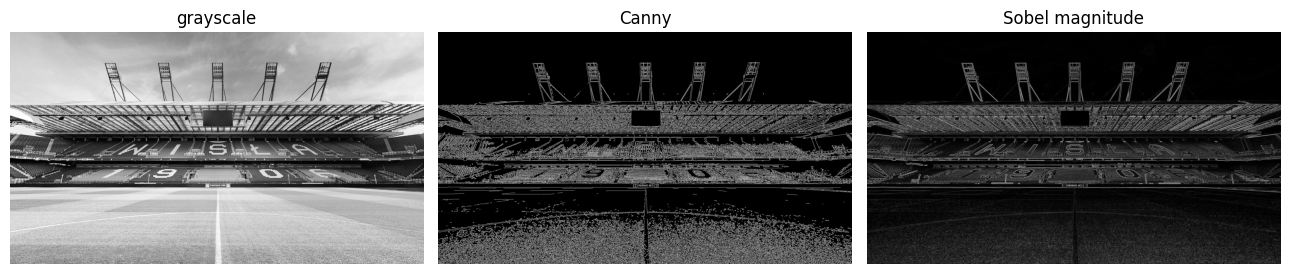

In [9]:
edges = canny_edges(img, low=100, high=200)
mag = sobel_edges(img)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(gray, cmap="gray");  axes[0].set_title("grayscale")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Canny")
axes[2].imshow(mag, cmap="gray");   axes[2].set_title("Sobel magnitude")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Tuning Canny thresholds

The (low, high) thresholds control how much detail survives. Sweep a few
to find a setting where the patch boundary is crisp but background
clutter is suppressed.

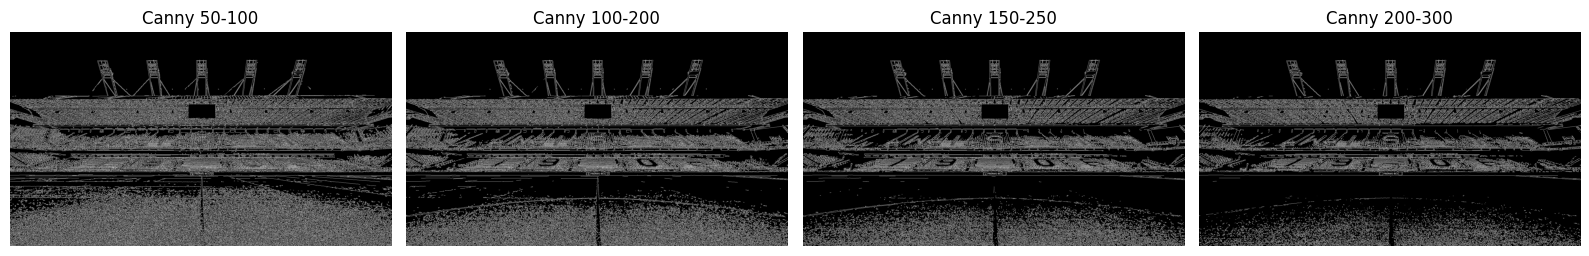

In [10]:
combos = [(50, 100), (100, 200), (150, 250), (200, 300)]

fig, axes = plt.subplots(1, len(combos), figsize=(16, 4))
for ax, (lo, hi) in zip(axes, combos):
    ax.imshow(canny_edges(img, lo, hi), cmap="gray")
    ax.set_title(f"Canny {lo}-{hi}")
    ax.axis("off")
plt.tight_layout()